# PCLab#1 - Group 4 - Claas Boumans Giuliano Ciaramella Theodor Nissen-Meyer

**20598 – Finance with Big Data · PC Lab #1: Applied Portfolio Theory**

**Setting.** We work for an old-school asset manager running a *regulated mutual fund*. The fund manager wants the weights of the **tangency (maximum-Sharpe) portfolio** built from eight US stocks that our broker trades without fees, and wants to know whether Markowitz mean-variance optimisation actually beats the market.

**Plan of the notebook**

| Task | What we do |
|---|---|
| 1 | Import the price data and describe the sample |
| 2 | Plot raw prices |
| 3 | Normalise prices to the first day and plot |
| 5 | Compute daily returns, correlations and return distributions |
| 6 | Simulate 10,000 random portfolios, find the tangency portfolio, draw the efficient frontier |
| 7 | Out-of-sample test: optimise on 2012–2015, invest over 2016–2020; yearly rebalancing |

*(The numbering follows the slides, which skip Task #4.)*

**Conventions used throughout**
- Returns are **simple daily returns**. A portfolio's simple return is the weighted sum of its assets' simple returns. That does not hold for log returns.
- Statistics are **annualised with 252 trading days**: mean × 252, volatility × √252.
- The Sharpe ratio uses a **risk-free rate of 0**. Rates were close to zero for most of 2012–2020, and this matches the slides. The rate is a single parameter below.
- A regulated mutual fund cannot short or use leverage, so portfolios are **long-only and fully invested**: $w_i \ge 0$, $\sum_i w_i = 1$.
- The **S&P 500 is the benchmark**. It is not an asset in the portfolio.

## 0. Setup
We import the libraries and collect every assumption in one place, so a parameter can be changed without searching through the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

pd.set_option("display.float_format", "{:,.4f}".format)
plt.rcParams.update({"figure.figsize": (14, 6), "axes.grid": True, "grid.alpha": 0.4})

DATA_PATH = "Data_PCLab1_Stock.csv"
BENCHMARK = "sp500"        # market index, used only as benchmark
TRADING_DAYS = 252         # annualisation factor
RISK_FREE = 0.0            # annual risk-free rate for the Sharpe ratio
N_PORTFOLIOS = 10_000      # number of random portfolios in the simulation
SEED = 42                  # fixed seed -> reproducible results
SPLIT_DATE = "2016-01-01"  # start of the out-of-sample period (Task 7)

## Task #1 – Import the data and describe the sample
We read the CSV, parse the `Date` column as dates, **sort chronologically** and use the date as the index. Every later step (returns, splits by year) needs the rows in time order.

In [2]:
def load_prices(path):
    # Read the price file, sort it by date and use Date as the index
    prices = pd.read_csv(path, parse_dates=["Date"])
    return prices.sort_values("Date").set_index("Date")


prices = load_prices(DATA_PATH)
stocks = [col for col in prices.columns if col != BENCHMARK]

print(f"Sample period : {prices.index.min():%Y-%m-%d} -> {prices.index.max():%Y-%m-%d}")
print(f"Trading days  : {len(prices)}")
print(f"Number of stocks: {len(stocks)} {stocks} (+ the S&P 500 index)")
prices.head()

Sample period : 2012-01-12 -> 2020-08-11
Trading days  : 2159
Number of stocks: 8 ['AAPL', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'TSLA', 'GOOG'] (+ the S&P 500 index)


,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.1986,75.5100,30.1200,12.1300,175.9300,180.5500,28.2500,313.6444,"1,295.5000"
2012-01-13,59.9729,74.6000,30.0700,12.3500,178.4200,179.1600,22.7900,311.3281,"1,289.0900"
2012-01-17,60.6714,75.2400,30.2500,12.2500,181.6600,180.0000,26.6000,313.1164,"1,293.6700"
2012-01-18,61.3014,75.0600,30.3300,12.7300,189.4400,181.0700,26.8100,315.2733,"1,308.0400"
2012-01-19,61.1071,75.5600,30.4200,12.8000,194.4500,180.5200,26.7600,318.5909,"1,314.5000"


**Null values.** Missing prices would silently break returns and covariances, so we check before going further.

In [3]:
null_counts = prices.isnull().sum()
print(null_counts.to_string())
print(f"\nDataset contains null values: {prices.isnull().values.any()}")
print(f"Duplicate dates: {prices.index.duplicated().sum()}")

AAPL     0
BA       0
T        0
MGM      0
AMZN     0
IBM      0
TSLA     0
GOOG     0
sp500    0

Dataset contains null values: False
Duplicate dates: 0


**Descriptive statistics.** `describe()` answers the three questions in one table. We also add the *coefficient of variation* (std / mean). The standard deviation in dollars depends on the price level, so an expensive stock looks "dispersed" just because it is expensive.

In [4]:
summary = prices.describe().T
summary["coef_var"] = summary["std"] / summary["mean"]
summary

,count,mean,std,min,25%,50%,75%,max,coef_var
AAPL,"2,159.0000",140.8198,70.8276,55.7900,89.1657,116.6000,175.0200,455.6100,0.5030
BA,"2,159.0000",189.9427,103.6786,67.2400,124.0150,142.4200,297.0450,440.6200,0.5458
T,"2,159.0000",35.1629,3.2075,26.7700,33.0400,34.9300,37.4200,43.4700,0.0912
MGM,"2,159.0000",23.1057,6.9638,7.1400,18.5450,23.7800,28.4300,38.0300,0.3014
AMZN,"2,159.0000",915.6657,697.8389,175.9300,316.4900,676.0100,"1,593.6450","3,225.0000",0.7621
IBM,"2,159.0000",161.8530,25.5619,94.7700,142.7700,156.9500,185.9750,215.8000,0.1579
TSLA,"2,159.0000",259.6008,210.9880,22.7900,184.5950,231.9600,307.3500,"1,643.0000",0.8127
GOOG,"2,159.0000",783.7125,334.4481,278.4812,527.2144,737.6000,"1,079.7450","1,568.4900",0.4267
sp500,"2,159.0000","2,218.7496",537.3217,"1,278.0400","1,847.9850","2,106.6299","2,705.8101","3,386.1499",0.2422


In [5]:
dollar_std = prices.std()

print(f"Average value of the S&P 500      : {prices[BENCHMARK].mean():,.2f} points")
print(f"Minimum dispersion (std in $)     : {dollar_std.idxmin()} (std = {dollar_std.min():.2f} $)")
print(f"Minimum relative dispersion (CV)  : {summary['coef_var'].idxmin()} (CV = {summary['coef_var'].min():.3f})")
print(f"Maximum Amazon price              : {prices['AMZN'].max():,.2f} $ on {prices['AMZN'].idxmax():%Y-%m-%d}")

Average value of the S&P 500      : 2,218.75 points
Minimum dispersion (std in $)     : T (std = 3.21 $)
Minimum relative dispersion (CV)  : T (CV = 0.091)
Maximum Amazon price              : 3,225.00 $ on 2020-08-06


**Answers – Task #1**
- **Sample.** 2,159 trading days from 2012-01-12 to 2020-08-11, with **8 stocks** (AAPL, BA, T, MGM, AMZN, IBM, TSLA, GOOG) plus the S&P 500 index. There are **no null values** and no duplicate dates, so no cleaning is needed.
- **Average S&P 500 value:** **2,218.75 points** over the period.
- **Minimum dispersion in dollar value:** **AT&T (T)**, with a standard deviation of only **\$3.21** (price range \$26.77–\$43.47). Dollar dispersion partly reflects AT&T's low share price, so we also checked the coefficient of variation. AT&T is lowest on that measure too (0.09), so its price really was the most stable. It is a mature, dividend-paying telecom company with little growth in its share price.
- **Maximum Amazon price:** **\$3,225.00**, reached on **2020-08-06**, near the end of the sample during the COVID-19 e-commerce boom.

## Task #2 – Plot the data
We write one reusable plotting function. It takes a DataFrame, draws every column against the date index and **returns nothing**. We reuse it for prices, normalised prices and returns.

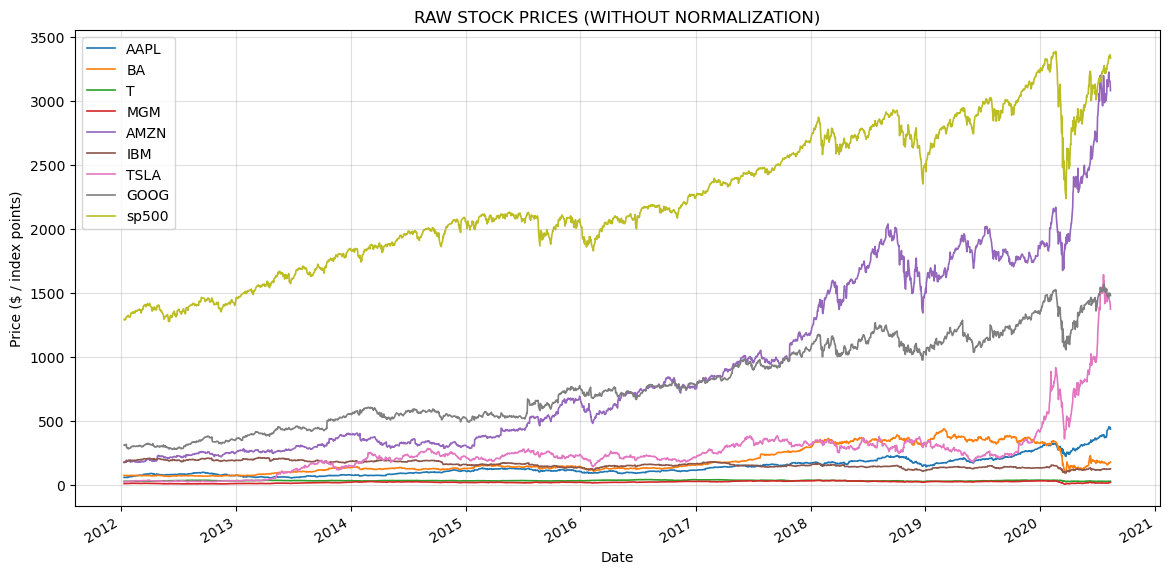

In [6]:
def plot_financial_data(df, title="", ylabel=""):
    # Plot every column of df against its date index (returns nothing)
    ax = df.plot(figsize=(14, 7), linewidth=1.2)
    ax.set_title(title.upper())
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper left")
    plt.show()


plot_financial_data(prices, "Raw stock prices (without normalization)", "Price ($ / index points)")

The raw chart mostly shows **price levels**: the S&P 500 (≈1,300–3,400 points), Amazon and Google dominate the scale, and T, MGM, IBM, AAPL and BA sit near the bottom. Price levels say nothing about performance, because a \$30 stock can grow faster than a \$3,000 one. That is why Task 3 normalises the series.

## Task #3 – Normalized (scaled) stock prices
We divide every series by its price on the first day (2012-01-12). All series then start at 1, and a value of 3 means the asset has **tripled**. This is the growth of \$1 invested on day one (buy-and-hold, dividends ignored).

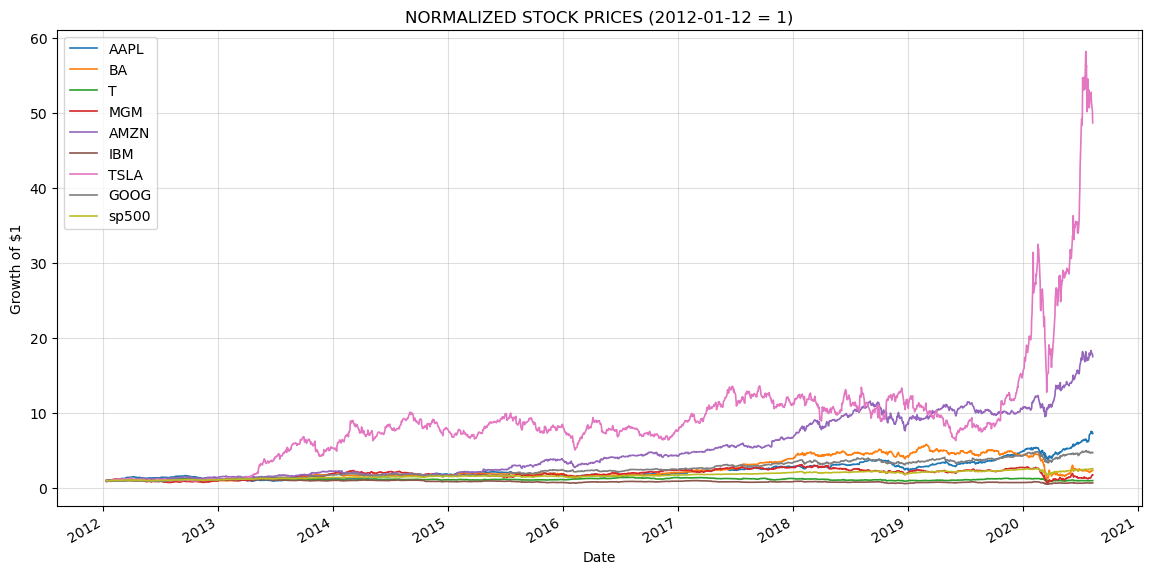

Value of $1 invested on 2012-01-12 at the end of the sample:
TSLA    48.6500
AMZN    17.5100
AAPL     7.2700
GOOG     4.7200
sp500    2.5700
BA       2.3900
MGM      1.7700
T        1.0000
IBM      0.7000


In [7]:
def normalize(df):
    # Divide each column by its first value, so every series starts at 1
    return df / df.iloc[0]


normalized_prices = normalize(prices)
plot_financial_data(normalized_prices, "Normalized stock prices (2012-01-12 = 1)", "Growth of $1")

growth = normalized_prices.iloc[-1].sort_values(ascending=False)
print("Value of $1 invested on 2012-01-12 at the end of the sample:")
print(growth.round(2).to_string())

**Comment.** Normalising shows performance instead of price level, and the ranking changes completely compared with Task 2:
- **Tesla** turned \$1 into **\$48.65**, and most of that gain came in 2020. **Amazon** (×17.5), **Apple** (×7.3) and **Google** (×4.7) also beat the S&P 500 (×2.57) by a wide margin.
- **Boeing** (×2.39) was far ahead of the market until its peak in March 2019. The 737 MAX grounding and then the 2020 travel collapse erased most of that lead. **MGM** (×1.77) was hit hard by the COVID-19 closure of casinos.
- **AT&T** ended exactly where it started (×1.00), and **IBM** lost 30% (×0.70). These are price-only figures. Both are high-dividend stocks, so their total returns were somewhat better.

⚠️ The universe contains several of the decade's biggest winners (Tesla, Amazon, Apple, Google). A portfolio built from these stocks with 2020 data benefits from **look-ahead / selection bias**, which matters when we judge "beating the market" in Tasks 6–7.

## Task #5 – Stock returns
### 5.1 Daily returns
Portfolio theory works with **returns**, not prices. The simple daily return is

$$r_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1 .$$

As the slides ask, the function loops over each stock and then over each row. The first day has no previous price, so its return is undefined and we drop it. Filling it with 0 would bias the mean and variance slightly. Afterwards we check the loop against pandas' vectorised `pct_change()`.

In [8]:
def daily_returns(df):
    # Simple daily returns P_t / P_{t-1} - 1, computed with explicit loops
    returns = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)

    for stock in df.columns:                      # loop through each stock
        price = df[stock].to_numpy()
        stock_returns = np.full(len(price), np.nan)   # day 0 has no return
        for t in range(1, len(price)):            # loop through each row of that stock
            stock_returns[t] = price[t] / price[t - 1] - 1
        returns[stock] = stock_returns

    return returns.dropna()


returns = daily_returns(prices)

# Sanity check against the vectorised pandas implementation
assert np.allclose(returns, prices.pct_change().dropna())
print(f"Loop implementation matches pct_change(): True  |  shape = {returns.shape}")
returns.head()

Loop implementation matches pct_change(): True  |  shape = (2158, 9)


,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-13,-0.0037,-0.0121,-0.0017,0.0181,0.0142,-0.0077,-0.1933,-0.0074,-0.0049
2012-01-17,0.0116,0.0086,0.0060,-0.0081,0.0182,0.0047,0.1672,0.0057,0.0036
2012-01-18,0.0104,-0.0024,0.0026,0.0392,0.0428,0.0059,0.0079,0.0069,0.0111
2012-01-19,-0.0032,0.0067,0.0030,0.0055,0.0264,-0.0030,-0.0019,0.0105,0.0049
2012-01-20,-0.0174,-0.0005,0.0030,-0.0125,-0.0181,0.0443,-0.0060,-0.0838,0.0007


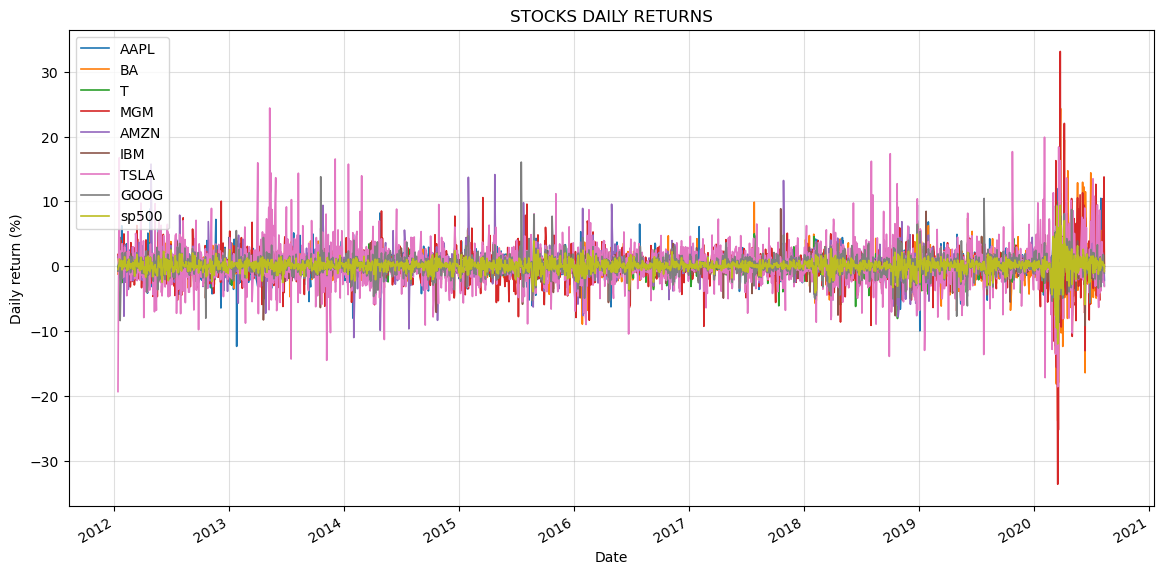

In [9]:
plot_financial_data(returns * 100, "Stocks daily returns", "Daily return (%)")

**Comment.** Unlike prices, returns have no trend. They fluctuate around zero, which is why we model returns rather than prices. Two features stand out:
- **Volatility clustering.** Calm periods alternate with turbulent ones. The March 2020 COVID-19 crash dominates the chart: MGM lost **−33.6%** on 2020-03-16 and gained **+33.1%** on 2020-03-24, and Boeing moved −23.8% and +24.3% on almost the same days.
- **Tesla (pink) is the most volatile stock throughout the sample**, not only in 2020 (e.g. −19.3% on 2012-01-13 and +24.4% on 2013-05-09). The S&P 500 moves the least, as expected for a diversified index.

Volatility clearly changes over time, while Markowitz uses one constant covariance matrix for the whole sample. This matters in Task 7.

### 5.2 Correlations between daily returns
Diversification depends on correlation. Assets that do not move together cancel part of each other's risk. We compute the Pearson correlation matrix of daily returns and show it as a heat-map.

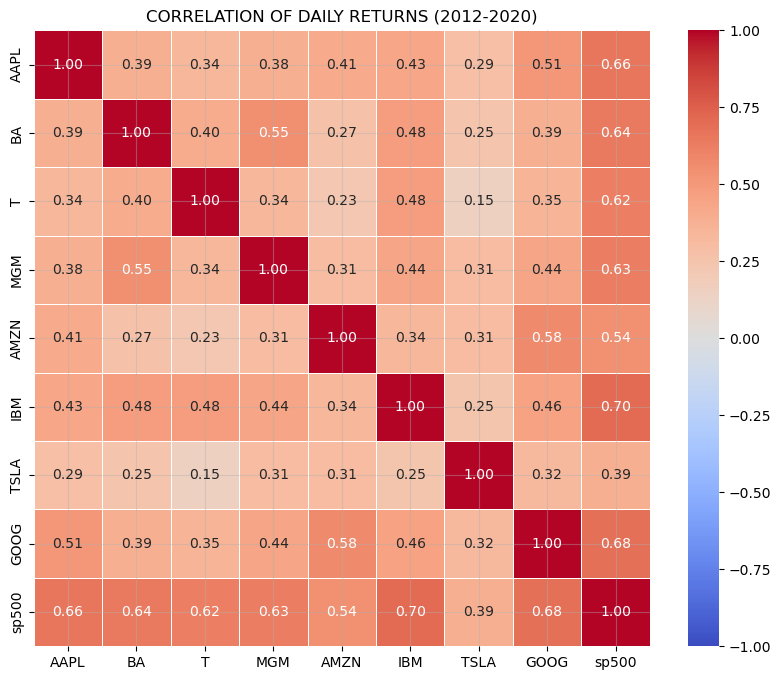

In [10]:
corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("CORRELATION OF DAILY RETURNS (2012-2020)")
plt.show()

In [11]:
corr_with_market = corr[BENCHMARK].drop(BENCHMARK).sort_values(ascending=False)
print("Correlation with the S&P 500:")
print(corr_with_market.round(3).to_string())
print(f"\nTop 2 stocks most positively correlated with the S&P 500: {list(corr_with_market.index[:2])}")

print(f"\nCorrelation AMZN - BA : {corr.loc['AMZN', 'BA']:.3f}")
print(f"Correlation MGM  - BA : {corr.loc['MGM', 'BA']:.3f}")

Correlation with the S&P 500:
IBM    0.7040
GOOG   0.6850
AAPL   0.6570
BA     0.6420
MGM    0.6310
T      0.6170
AMZN   0.5400
TSLA   0.3880

Top 2 stocks most positively correlated with the S&P 500: ['IBM', 'GOOG']

Correlation AMZN - BA : 0.267
Correlation MGM  - BA : 0.554


The full-sample correlation hides how relationships change over time. The COVID-19 shock in 2020 is a natural experiment, so we compare the two pairs before and during 2020.

In [12]:
def pair_correlation_by_period(returns, pairs, split="2020-01-01"):
    # Correlation of each (a, b) pair before and after a split date
    before, after = returns[returns.index < split], returns[returns.index >= split]
    rows = {f"{a} - {b}": {f"before {split[:4]}": before[a].corr(before[b]),
                           f"from {split[:4]}": after[a].corr(after[b]),
                           "full sample": returns[a].corr(returns[b])}
            for a, b in pairs}
    return pd.DataFrame(rows).T


pair_correlation_by_period(returns, [("AMZN", "BA"), ("MGM", "BA")])

,before 2020,from 2020,full sample
AMZN - BA,0.3229,0.2853,0.2675
MGM - BA,0.3600,0.7193,0.5542


**Comments – Task #5 (correlations)**
- **Every stock is positively correlated with the market and with every other stock** (0.15 to 0.70). A common market factor drives all of them. Diversification can reduce risk but cannot remove it.
- **Top 2 stocks correlated with the S&P 500: IBM (0.704) and Google (0.685)**, followed closely by Apple (0.657). These are large, diversified companies with heavy index weights. Their revenues follow the broad economy, so they behave most like "the market". Tesla is the least market-like stock (0.388): its returns were driven mainly by company-specific news.
- **Amazon – Boeing: 0.267**, one of the lowest pairs (only T–TSLA is lower at 0.15). The businesses have little in common. Amazon is a tech/e-commerce growth company, while Boeing is a cyclical industrial whose returns depended on aircraft orders and, from 2019, the 737 MAX crisis. The pair stayed weakly correlated in 2020 (0.29), when lockdowns helped Amazon and devastated Boeing. **This is a good diversification pair**.
- **MGM – Boeing: 0.554**, the second-highest pair among the stocks (after AMZN–GOOG, 0.575). Both companies depend on **travel, leisure and the business cycle**. The split-sample table shows a sharp rise: 0.36 before 2020, **0.72 during 2020**, when the pandemic grounded planes and closed casinos at the same time. **Correlations rise in crises**, exactly when investors need diversification most. A covariance matrix estimated in calm times therefore understates crash risk.

### 5.3 Distribution of daily returns
Mean-variance theory summarises each asset by its mean and variance, which is fully adequate only if returns are roughly normal. We plot histograms with a fitted normal density on top and report skewness and excess kurtosis (a normal distribution has 0 for both).

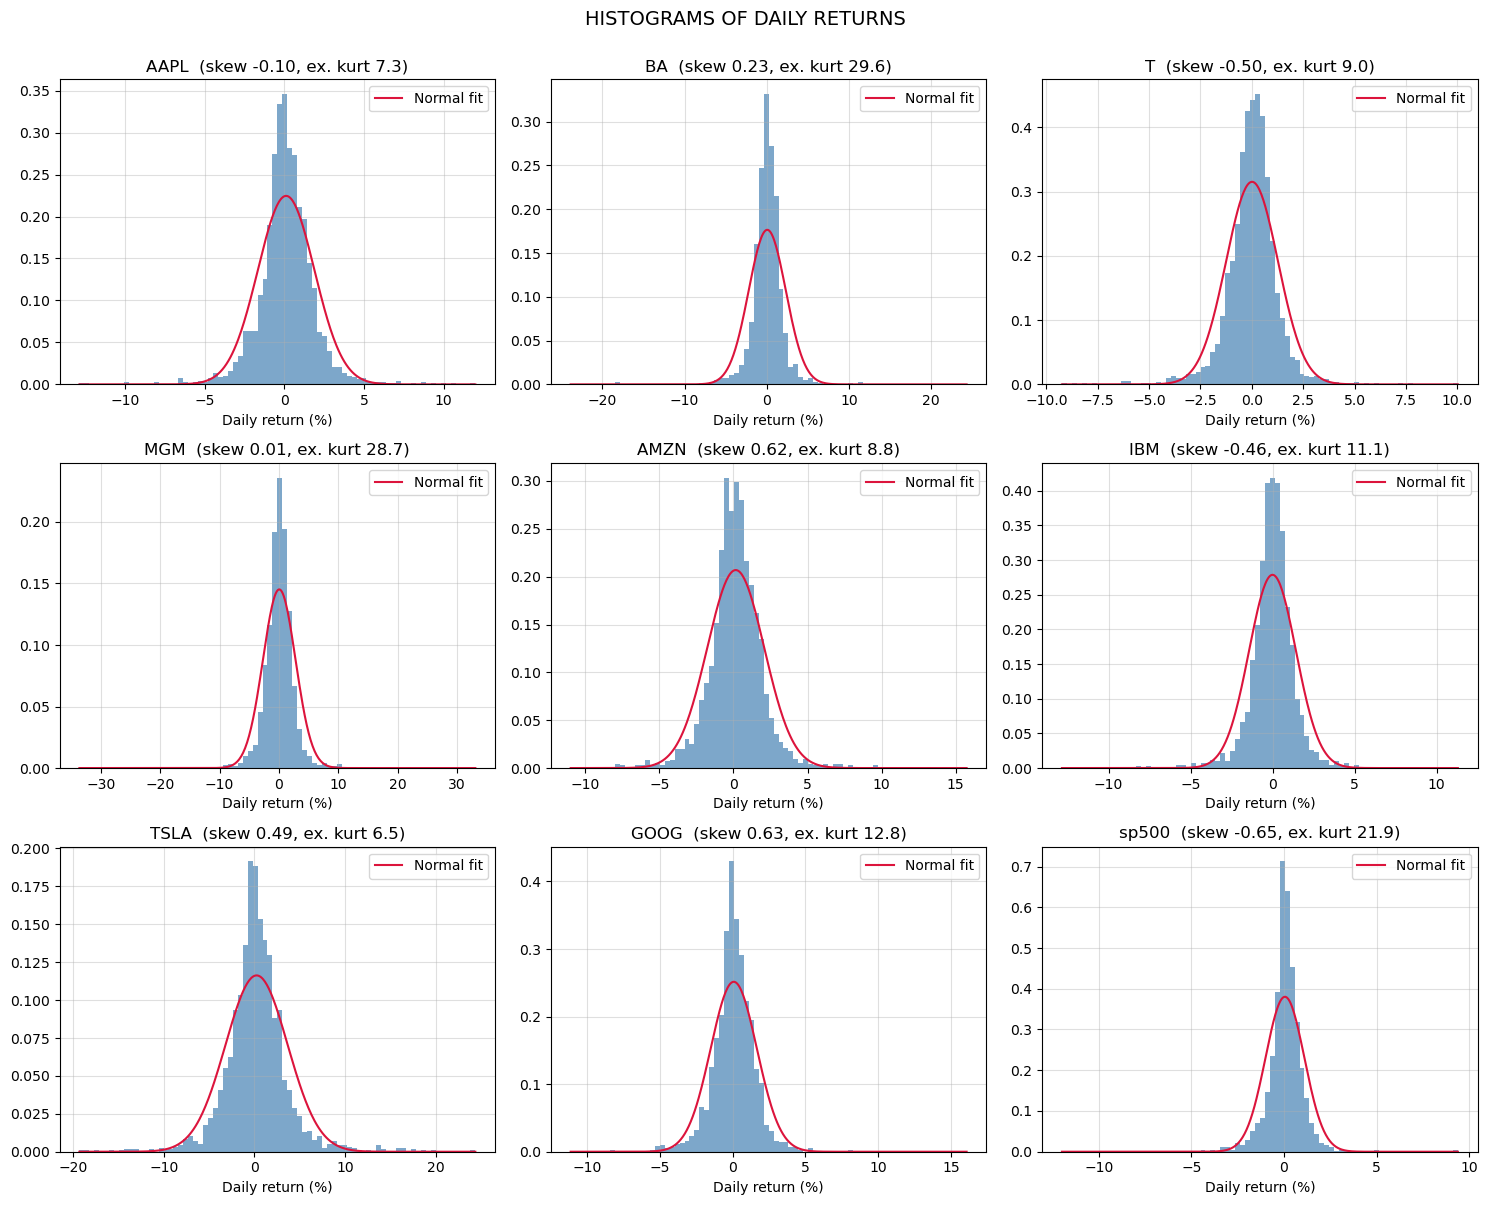

In [13]:
def plot_return_histograms(returns, bins=80):
    # One histogram per column, with the normal density of the same mean/std on top
    n_cols = 3
    n_rows = int(np.ceil(returns.shape[1] / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

    for ax, col in zip(axes.flat, returns.columns):
        r = returns[col] * 100
        ax.hist(r, bins=bins, density=True, alpha=0.7, color="steelblue")
        x = np.linspace(r.min(), r.max(), 400)
        pdf = np.exp(-0.5 * ((x - r.mean()) / r.std()) ** 2) / (r.std() * np.sqrt(2 * np.pi))
        ax.plot(x, pdf, color="crimson", lw=1.5, label="Normal fit")
        ax.set_title(f"{col}  (skew {r.skew():.2f}, ex. kurt {r.kurt():.1f})")
        ax.set_xlabel("Daily return (%)")
        ax.legend()

    for ax in axes.flat[returns.shape[1]:]:     # hide unused subplots
        ax.axis("off")
    fig.suptitle("HISTOGRAMS OF DAILY RETURNS", y=1.00, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_return_histograms(returns)

In [14]:
def return_statistics(returns):
    # Annualised mean/vol plus shape statistics of daily returns
    return pd.DataFrame({
        "ann. mean": returns.mean() * TRADING_DAYS,
        "ann. vol": returns.std() * np.sqrt(TRADING_DAYS),
        "skewness": returns.skew(),
        "excess kurtosis": returns.kurt(),
        "worst day": returns.min(),
        "best day": returns.max(),
    }).sort_values("ann. vol", ascending=False)


return_statistics(returns)

,ann. mean,ann. vol,skewness,excess kurtosis,worst day,best day
TSLA,0.6010,0.5446,0.4881,6.5244,-0.1933,0.2440
MGM,0.1630,0.4361,0.0075,28.7096,-0.3361,0.3311
BA,0.1662,0.3588,0.2273,29.5818,-0.2385,0.2432
AMZN,0.3810,0.3061,0.6201,8.7650,-0.1100,0.1575
AAPL,0.2715,0.2820,-0.0979,7.3196,-0.1286,0.1198
GOOG,0.2128,0.2518,0.6349,12.7677,-0.1110,0.1605
IBM,-0.0154,0.2272,-0.4641,11.0543,-0.1285,0.1130
T,0.0206,0.2008,-0.4975,9.0267,-0.0924,0.1002
sp500,0.1243,0.1665,-0.6516,21.8711,-0.1198,0.0938


**Comment – distributions.**
- All distributions are **centred close to zero** and look bell-shaped, but they are **not normal**. The peaks are too tall and the tails too fat compared with the red normal curve. Excess kurtosis ranges from 6.5 (TSLA) to **29.6 (BA)** and **28.7 (MGM)**, against 0 for a normal distribution. A day like MGM's −33.6% is practically impossible under a normal distribution with a 2.7% daily standard deviation.
- **Histogram width reflects volatility.** Tesla has the widest distribution (54% annualised volatility), then MGM (44%) and Boeing (36%). AT&T is the narrowest stock (20%), and the S&P 500 is narrower still (17%) thanks to diversification.
- **Skewness differs in sign.** The S&P 500 (−0.65), AT&T and IBM are negatively skewed, meaning occasional large losses. Amazon, Google and Tesla are positively skewed, with large jumps upward (e.g. earnings surprises).

**Implication.** Mean-variance analysis treats upside and downside moves symmetrically and summarises risk by variance alone. With fat tails and skewness, variance **understates tail risk**, so Sharpe ratios in the next task should be read with that in mind.

**Optional – interactive histograms with Plotly.** `plotly.figure_factory.create_distplot` overlays all histograms with smoothed densities. You can hover, zoom and toggle series in the legend. Plotly is not a core dependency of this notebook, so the cell checks for it first.

In [15]:
def interactive_histograms(returns, bin_size=0.3):
    # Interactive overlaid histograms + KDE of daily returns (%) using Plotly's figure factory
    try:
        import plotly.figure_factory as ff
    except ImportError:
        print("Plotly is not installed in this environment -> run `pip install plotly` to see this chart.")
        return

    data = [(returns[col] * 100).to_numpy() for col in returns.columns]
    fig = ff.create_distplot(data, list(returns.columns), bin_size=bin_size, show_rug=False)
    fig.update_layout(title="Distribution of daily returns (%)", xaxis_title="Daily return (%)",
                      width=1000, height=550)
    fig.show()


interactive_histograms(returns)

Plotly is not installed in this environment -> run `pip install plotly` to see this chart.


## Task #6 – Portfolio weights
### 6.1 Simulation: the empirical efficient frontier
For a weight vector $w$ and the daily mean vector $\mu$ and covariance matrix $\Sigma$ of the stocks:

$$E[R_p] = 252\, w^\top \mu, \qquad \sigma_p = \sqrt{252\, w^\top \Sigma\, w}, \qquad SR_p = \frac{E[R_p]-r_f}{\sigma_p}.$$

We draw 10,000 random long-only weight vectors: uniform draws rescaled to sum to 1, as in the slides. For each one we compute return, variance, volatility and Sharpe ratio and keep the portfolio with the **maximum Sharpe ratio**. That is the simulated **tangency portfolio**.

The helpers are generic in the returns they receive, so Task 7 can reuse them on sub-samples. The simulation uses matrix algebra (one matrix product for all 10,000 portfolios) instead of a Python loop.

In [16]:
def portfolio_performance(weights, returns, rf=RISK_FREE):
    # Annualised expected return, volatility and Sharpe ratio of one weight vector
    weights = np.asarray(weights)
    exp_return = weights @ returns.mean().to_numpy() * TRADING_DAYS
    volatility = np.sqrt(weights @ returns.cov().to_numpy() @ weights * TRADING_DAYS)
    return exp_return, volatility, (exp_return - rf) / volatility


def simulate_portfolios(returns, n_portfolios=N_PORTFOLIOS, rf=RISK_FREE, seed=SEED):
    '''
    Simulate random long-only, fully invested portfolios.

    Returns
    -------
    max_sharpe : float          highest Sharpe ratio among the simulated portfolios
    best_weights : pd.Series    weights of that (tangency) portfolio
    results : pd.DataFrame      Return, Volatility, Variance, Sharpe of every portfolio
    '''
    rng = np.random.default_rng(seed)
    mu = returns.mean().to_numpy()
    cov = returns.cov().to_numpy()

    weights = rng.random((n_portfolios, len(mu)))
    weights /= weights.sum(axis=1, keepdims=True)            # each row sums to 1

    port_return = weights @ mu * TRADING_DAYS
    port_variance = np.einsum("ij,jk,ik->i", weights, cov, weights) * TRADING_DAYS  # w' S w row by row
    port_vol = np.sqrt(port_variance)
    sharpe = (port_return - rf) / port_vol

    results = pd.DataFrame({"Return": port_return, "Volatility": port_vol,
                            "Variance": port_variance, "Sharpe": sharpe})
    best = sharpe.argmax()
    best_weights = pd.Series(weights[best], index=returns.columns, name="weight")
    return sharpe[best], best_weights, results

In [17]:
stock_returns = returns[stocks]
max_sharpe, tangency_weights, sim_results = simulate_portfolios(stock_returns)

tan_ret, tan_vol, _ = portfolio_performance(tangency_weights, stock_returns)
print(f"Maximum simulated Sharpe ratio : {max_sharpe:.3f}")
print(f"Expected annual return         : {tan_ret:.2%}")
print(f"Annual volatility              : {tan_vol:.2%}")
print("\nTangency portfolio weights (simulation):")
print(tangency_weights.sort_values(ascending=False).map("{:.2%}".format).to_string())

Maximum simulated Sharpe ratio : 1.426
Expected annual return         : 34.14%
Annual volatility              : 23.94%

Tangency portfolio weights (simulation):
AMZN    31.18%
AAPL    23.14%
TSLA    18.97%
GOOG    17.29%
BA       4.25%
T        3.14%
IBM      1.19%
MGM      0.83%


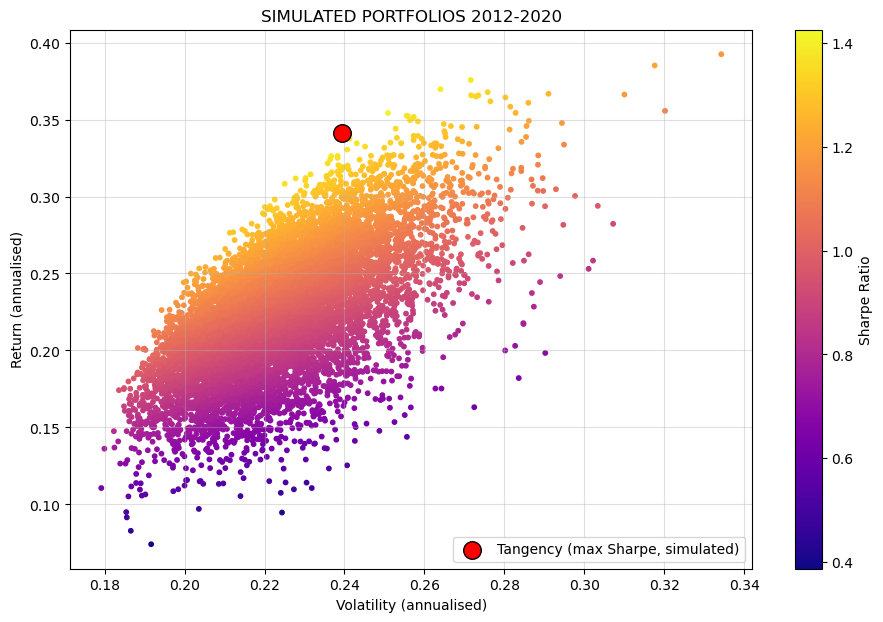

In [18]:
def plot_simulated_frontier(results, highlight=None, frontier=None, title=""):
    # Scatter the simulated portfolios coloured by Sharpe ratio; optionally mark points and a frontier line
    fig, ax = plt.subplots(figsize=(11, 7))
    sc = ax.scatter(results["Volatility"], results["Return"], c=results["Sharpe"], cmap="plasma", s=10)
    fig.colorbar(sc, ax=ax, label="Sharpe Ratio")

    if frontier is not None:
        # upper branch (above the minimum-variance point) is efficient, lower branch is dominated
        split = frontier["Volatility"].idxmin()
        upper, lower = frontier.loc[split:], frontier.loc[:split]
        ax.plot(upper["Volatility"], upper["Return"], color="green", lw=2.5, label="Efficient frontier (optimiser)")
        ax.plot(lower["Volatility"], lower["Return"], color="green", lw=1.5, ls="--", label="Inefficient branch")
    for label, (vol, ret, style) in (highlight or {}).items():
        ax.scatter(vol, ret, s=160, edgecolors="black", label=label, **style, zorder=3)

    ax.set_xlabel("Volatility (annualised)")
    ax.set_ylabel("Return (annualised)")
    ax.set_title(title.upper())
    if highlight or frontier is not None:
        ax.legend(loc="lower right")
    plt.show()


plot_simulated_frontier(
    sim_results,
    highlight={"Tangency (max Sharpe, simulated)": (tan_vol, tan_ret, {"color": "red"})},
    title="Simulated portfolios 2012-2020",
)

**Tangency portfolio weights (2012–2020, simulation):** AMZN 31.2%, AAPL 23.1%, TSLA 19.0%, GOOG 17.3%, BA 4.2%, T 3.1%, IBM 1.2%, MGM 0.8%.
It has an **expected return of 34.1%, volatility of 23.9% and a Sharpe ratio of 1.43**, almost twice the S&P 500's Sharpe ratio (0.75).

**Interpretation**
- The cloud has the typical "bullet" shape from the slides. Its upper-left edge is the **empirical efficient frontier**, and the tangency portfolio (red) sits on that edge, where the ratio of return to risk is highest.
- About 90% of the weight goes to the **four tech winners**. They have the highest average returns (27–60% p.a.) and only moderate correlations with each other. Tesla has the highest mean return (60%) but gets less than 20% because of its 54% volatility. AT&T and IBM have low volatility but near-zero mean returns, so the optimiser barely uses them. **Expected returns drive the solution far more than volatilities do.**
- **Caveat: these means are very noisy.** The standard error of an annualised mean is σ/√years ≈ 30% / √8.6 ≈ **10 percentage points** for a typical stock here. The weights therefore rest on estimates that are highly uncertain.
- **Regulatory remark.** A real regulated fund would face concentration limits. For example, the EU UCITS "5/10/40" rule caps any single issuer at 10% of assets, which a 31% Amazon position would breach. Such limits are easy to add as upper bounds on the weights.

### 6.2 Performance of the tangency portfolio over the sample
We invest \$1 on 2012-01-12 and compare it with the S&P 500 and with a naive **equal-weight (1/N)** portfolio of the same 8 stocks. The broker charges no fees, so we assume the portfolio is **rebalanced back to its target weights every day** (constant mix). That is exactly the portfolio whose mean and variance we optimised. For reference we also show the **buy-and-hold** version, where weights are set once and then drift with prices.

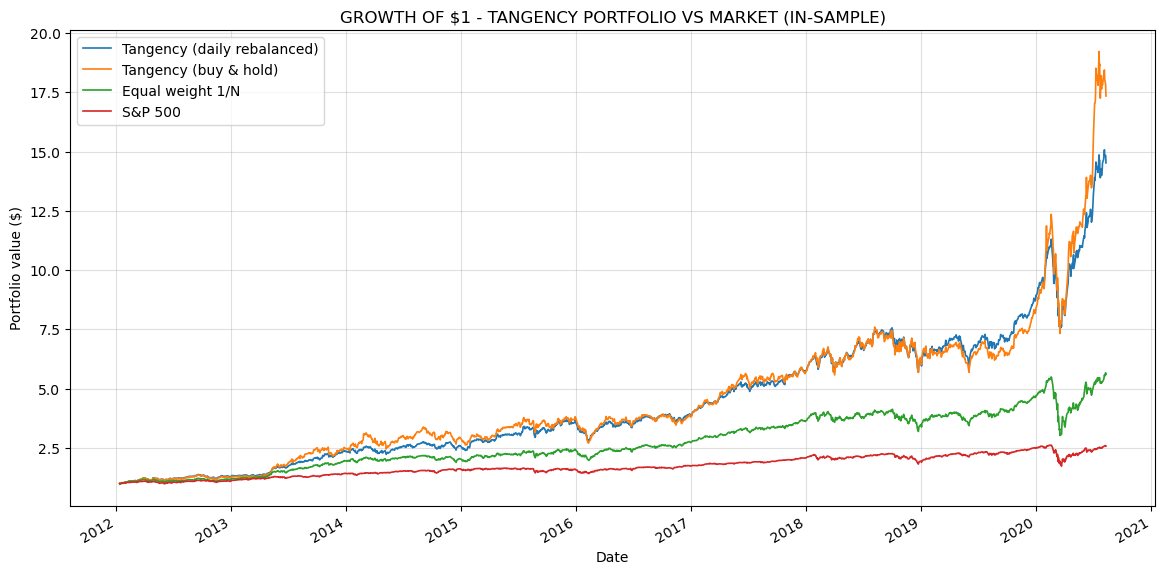

,total return,CAGR,ann. mean return,ann. vol,Sharpe,max drawdown
Tangency (daily rebalanced),13.5235,0.3668,0.3414,0.2394,1.4261,-0.3380
Tangency (buy & hold),16.3451,0.3952,0.3762,0.2931,1.2836,-0.4071
Equal weight 1/N,4.5974,0.2228,0.2251,0.2178,1.0334,-0.4499
S&P 500,1.5733,0.1166,0.1243,0.1665,0.7464,-0.3392


In [19]:
def portfolio_value(returns, weights, start_value=1.0):
    # Value of a constant-mix portfolio (rebalanced daily to `weights`)
    daily = returns[weights.index] @ weights
    return start_value * (1 + daily).cumprod()


def performance_summary(values, rf=RISK_FREE):
    # Realised CAGR, annualised volatility, Sharpe ratio and max drawdown of value series
    stats = {}
    for name, v in values.items():
        v = v.dropna()
        daily = v.pct_change()
        daily.iloc[0] = v.iloc[0] - 1                # every series is the growth of $1 invested before day 1
        years = len(daily) / TRADING_DAYS
        cagr = v.iloc[-1] ** (1 / years) - 1
        vol = daily.std() * np.sqrt(TRADING_DAYS)
        stats[name] = {"total return": v.iloc[-1] - 1,
                       "CAGR": cagr,
                       "ann. mean return": daily.mean() * TRADING_DAYS,
                       "ann. vol": vol,
                       "Sharpe": (daily.mean() * TRADING_DAYS - rf) / vol,
                       "max drawdown": (v / v.cummax() - 1).min()}
    return pd.DataFrame(stats).T


equal_weights = pd.Series(1 / len(stocks), index=stocks)

values_full = pd.DataFrame({
    "Tangency (daily rebalanced)": portfolio_value(returns, tangency_weights),
    "Tangency (buy & hold)": normalized_prices[stocks] @ tangency_weights,
    "Equal weight 1/N": portfolio_value(returns, equal_weights),
    "S&P 500": normalized_prices[BENCHMARK],
})
plot_financial_data(values_full, "Growth of $1 - tangency portfolio vs market (in-sample)", "Portfolio value ($)")
performance_summary(values_full)

**Comment – in-sample performance.** \$1 invested in the tangency portfolio on 2012-01-12 grows to **\$14.52** (CAGR 36.7%) with daily rebalancing, or **\$17.35** buy-and-hold. The equal-weight portfolio reaches \$5.60 (CAGR 22.3%) and the **S&P 500 only \$2.57** (CAGR 11.7%). The rebalanced portfolio's realised Sharpe ratio (1.43) matches the simulated one exactly, which confirms that the performance code is consistent with the optimisation. The buy-and-hold version ends higher but with more risk (volatility 29%, Sharpe 1.28). Without rebalancing, the weights drift towards the fastest-growing stocks (Tesla, Amazon), so the portfolio becomes more concentrated. The tangency portfolio's maximum drawdown during the COVID crash (−33.8%) was about the same as the market's (−33.9%).

**This looks like a clear win over the market, but it is not a fair test.** We chose both the weights and the stocks knowing how 2012–2020 turned out. Task 7 removes the look-ahead in the weights.

### 6.3 Optional – the efficient frontier via optimisation
Random weights rarely land exactly on the frontier. The simulated cloud only *approaches* it from the inside, and adding assets makes that worse. Instead, for every target return $\bar R$ we solve

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad 252\,w^\top\mu = \bar R,\;\; \textstyle\sum_i w_i = 1,\;\; 0 \le w_i \le 1$$

with SciPy's SLSQP solver. We solve it on a grid of targets between the lowest and highest single-stock return, which is the feasible range for a long-only portfolio. With the same solver we also maximise the Sharpe ratio directly, which gives the *exact* tangency portfolio to compare with the simulated one. Variance is annualised inside the objective so that its scale suits the solver's tolerance.

In [20]:
LONG_ONLY = "long_only"


def _optimise(objective, n_assets, extra_constraints=()):
    # Minimise objective(w) over long-only, fully invested weights
    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}, *extra_constraints]
    res = minimize(objective, x0=np.full(n_assets, 1 / n_assets), method="SLSQP",
                   bounds=[(0, 1)] * n_assets, constraints=constraints,
                   options={"ftol": 1e-12, "maxiter": 1000})
    if not res.success:
        raise RuntimeError(res.message)
    return res.x


def min_variance_weights(returns, target_return):
    # Long-only weights with the lowest variance for a given annual target return
    mu = returns.mean().to_numpy() * TRADING_DAYS
    cov = returns.cov().to_numpy() * TRADING_DAYS
    target = {"type": "eq", "fun": lambda w: w @ mu - target_return}
    return _optimise(lambda w: w @ cov @ w, len(mu), [target])


def max_sharpe_weights(returns, rf=RISK_FREE):
    # Exact long-only tangency portfolio (maximises the Sharpe ratio)
    mu = returns.mean().to_numpy() * TRADING_DAYS
    cov = returns.cov().to_numpy() * TRADING_DAYS
    w = _optimise(lambda w: -(w @ mu - rf) / np.sqrt(w @ cov @ w), len(mu))
    return pd.Series(w, index=returns.columns, name="weight")


def efficient_frontier(returns, n_points=60):
    # Minimum-variance frontier: volatility for a grid of target returns
    annual_mu = returns.mean() * TRADING_DAYS
    targets = np.linspace(annual_mu.min(), annual_mu.max(), n_points)
    vols = [portfolio_performance(min_variance_weights(returns, t), returns)[1] for t in targets]
    return pd.DataFrame({"Return": targets, "Volatility": vols})

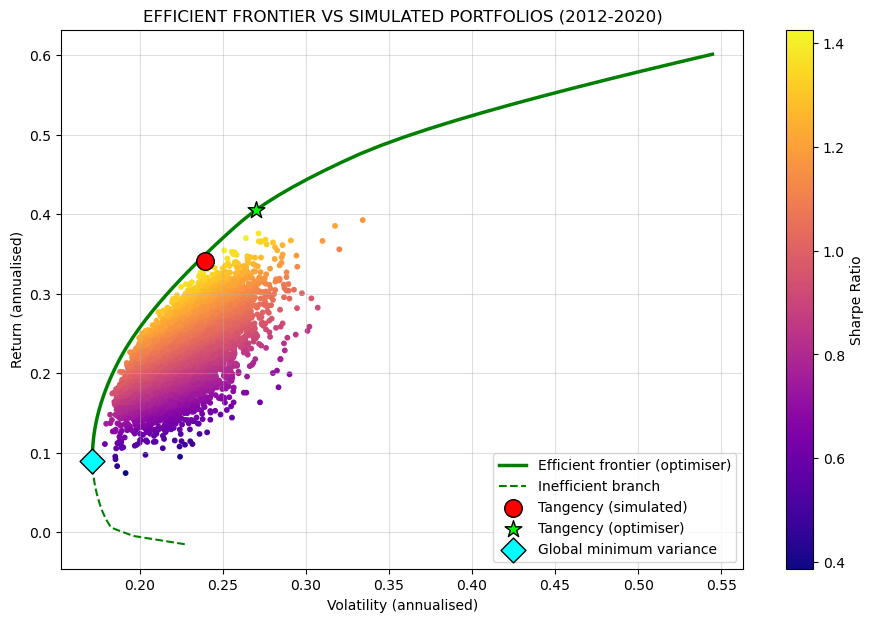

Tangency (simulated) : return 34.14% | vol 23.94% | Sharpe 1.426
Tangency (optimiser) : return 40.53% | vol 27.02% | Sharpe 1.500
Global min. variance : return 8.91% | vol 17.17%


,Tangency (simulated),Tangency (optimiser),Global min. variance
AAPL,23.1%,25.8%,7.3%
BA,4.2%,0.0%,0.0%
T,3.1%,0.0%,48.9%
MGM,0.8%,0.0%,0.0%
AMZN,31.2%,50.3%,9.2%
IBM,1.2%,0.0%,21.8%
TSLA,19.0%,23.9%,0.1%
GOOG,17.3%,0.0%,12.7%


In [21]:
frontier = efficient_frontier(stock_returns)
exact_tangency = max_sharpe_weights(stock_returns)
ex_ret, ex_vol, ex_sharpe = portfolio_performance(exact_tangency, stock_returns)
gmv = frontier.loc[frontier["Volatility"].idxmin()]

plot_simulated_frontier(
    sim_results,
    frontier=frontier,
    highlight={"Tangency (simulated)": (tan_vol, tan_ret, {"color": "red"}),
               "Tangency (optimiser)": (ex_vol, ex_ret, {"color": "lime", "marker": "*"}),
               "Global minimum variance": (gmv["Volatility"], gmv["Return"], {"color": "cyan", "marker": "D"})},
    title="Efficient frontier vs simulated portfolios (2012-2020)",
)

gmv_weights = min_variance_weights(stock_returns, gmv["Return"])
print(f"Tangency (simulated) : return {tan_ret:.2%} | vol {tan_vol:.2%} | Sharpe {max_sharpe:.3f}")
print(f"Tangency (optimiser) : return {ex_ret:.2%} | vol {ex_vol:.2%} | Sharpe {ex_sharpe:.3f}")
print(f"Global min. variance : return {gmv['Return']:.2%} | vol {gmv['Volatility']:.2%}")

pd.DataFrame({"Tangency (simulated)": tangency_weights,
              "Tangency (optimiser)": exact_tangency,
              "Global min. variance": pd.Series(gmv_weights, index=stocks)}).map("{:.1%}".format)

**Comment – efficient frontier.**
- The optimised frontier (green) **envelops the simulated cloud**. None of the 10,000 random portfolios lies beyond it, which confirms the optimiser works. The dashed lower branch is inefficient: for the same volatility, the upper branch offers a higher return. The frontier ends at 100% Tesla (60% return, 54% volatility), the highest-return asset.
- **The random simulation never reaches the frontier.** Uniform random weights that sum to 1 cluster around 1/8 per stock, so concentrated portfolios are almost never drawn. The **exact tangency portfolio** is a *corner solution*: **AMZN 50.3%, AAPL 25.8%, TSLA 23.9% and zero in the other five stocks**. It has a return of 40.5%, volatility of 27.0% and a **Sharpe ratio of 1.50** (versus 1.43 simulated).
- The **global minimum-variance portfolio** (volatility 17.2%, return 8.9%) looks completely different. About 49% goes to AT&T and 22% to IBM, the least volatile stocks. It needs no return forecasts at all.
- **Takeaway.** An unconstrained optimiser puts as much weight as possible on the assets with the **highest estimated means**, which are also the least reliable estimates. This is the "error-maximisation" problem of Markowitz optimisation. It motivates weight caps, shrinkage, or portfolios such as minimum variance that do not rely on expected returns.

## Task #7 – Testing portfolio theory
Everything in Task 6 is **in-sample**: we chose the weights using the same returns we then measured them on, i.e. with perfect hindsight. A real fund manager only knows the past. We therefore
1. estimate the tangency portfolio on **2012-01-13 → 2015-12-31** (estimation window),
2. hold those weights over **2016-01-04 → 2020-08-11** (out-of-sample window),
3. compare what the model *expected* with what was *realised*.

In [22]:
train = returns.loc[returns.index < SPLIT_DATE]
test = returns.loc[returns.index >= SPLIT_DATE]
print(f"Estimation window : {train.index.min():%Y-%m-%d} -> {train.index.max():%Y-%m-%d} ({len(train)} days)")
print(f"Test window       : {test.index.min():%Y-%m-%d} -> {test.index.max():%Y-%m-%d} ({len(test)} days)")

sharpe_train, weights_train, sim_train = simulate_portfolios(train[stocks])
exp_ret, exp_vol, exp_sharpe = portfolio_performance(weights_train, train[stocks])

print(f"\nIn-sample (2012-2015) max Sharpe: {sharpe_train:.3f} | expected return {exp_ret:.2%} | volatility {exp_vol:.2%}")
print("\nOptimal weights estimated on 2012-2015 vs full sample:")
pd.DataFrame({"2012-2015": weights_train, "2012-2020 (Task 6)": tangency_weights}).map("{:.2%}".format)

Estimation window : 2012-01-13 -> 2015-12-31 (998 days)
Test window       : 2016-01-04 -> 2020-08-11 (1160 days)

In-sample (2012-2015) max Sharpe: 1.655 | expected return 33.38% | volatility 20.17%

Optimal weights estimated on 2012-2015 vs full sample:


,2012-2015,2012-2020 (Task 6)
AAPL,10.39%,23.14%
BA,23.02%,4.25%
T,7.03%,3.14%
MGM,2.51%,0.83%
AMZN,26.72%,31.18%
IBM,0.38%,1.19%
TSLA,19.86%,18.97%
GOOG,10.08%,17.29%


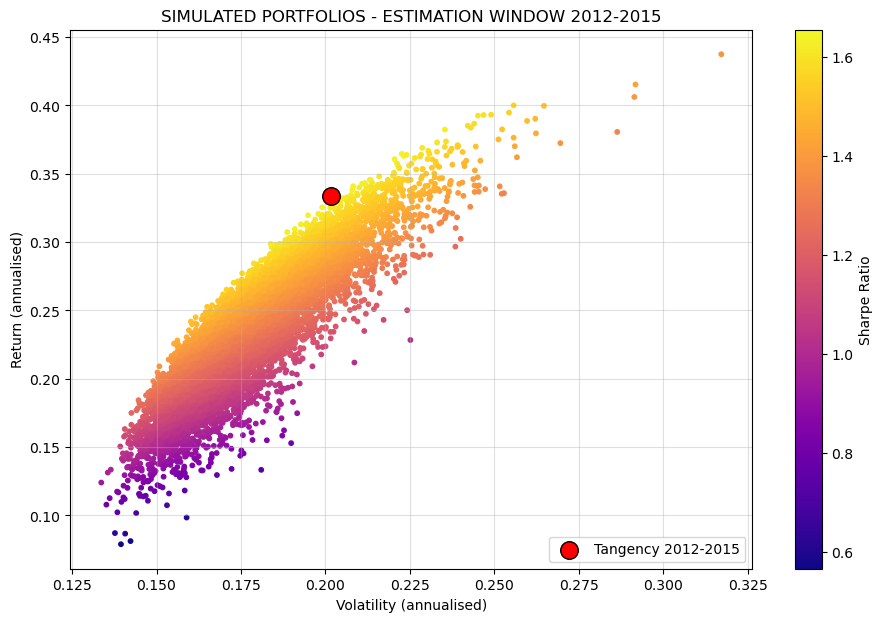

In [23]:
plot_simulated_frontier(
    sim_train,
    highlight={"Tangency 2012-2015": (exp_vol, exp_ret, {"color": "red"})},
    title="Simulated portfolios - estimation window 2012-2015",
)

**Out-of-sample performance.** We invest \$1 on the first day of 2016 in the 2012–2015 tangency portfolio and compare it with the S&P 500, the 1/N portfolio and the *ex-post* tangency portfolio of 2016–2020. The ex-post portfolio is the unattainable best case, since it needs perfect foresight.

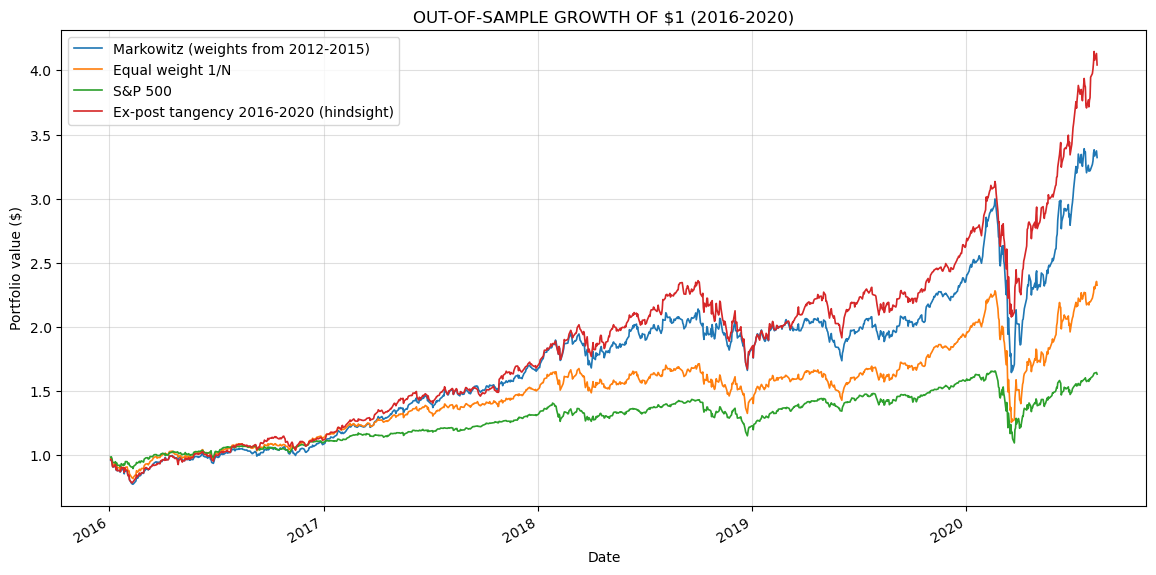

,total return,CAGR,ann. mean return,ann. vol,Sharpe,max drawdown
Markowitz (weights from 2012-2015),2.3207,0.2979,0.2980,0.2715,1.0976,-0.4517
Equal weight 1/N,1.3253,0.2012,0.2152,0.2510,0.8573,-0.4499
S&P 500,0.6310,0.1121,0.1252,0.1937,0.6463,-0.3392
Ex-post tangency 2016-2020 (hindsight),3.0426,0.3545,0.3370,0.2578,1.3071,-0.3373


In [24]:
weights_test_ex_post = simulate_portfolios(test[stocks])[1]

values_test = pd.DataFrame({
    "Markowitz (weights from 2012-2015)": portfolio_value(test, weights_train),
    "Equal weight 1/N": portfolio_value(test, equal_weights),
    "S&P 500": (1 + test[BENCHMARK]).cumprod(),
    "Ex-post tangency 2016-2020 (hindsight)": portfolio_value(test, weights_test_ex_post),
})
plot_financial_data(values_test, "Out-of-sample growth of $1 (2016-2020)", "Portfolio value ($)")
performance_summary(values_test)

**Expected vs realised.** For each strategy we compare the return and volatility measured over 2012–2015 (what an investor would have *expected*) with the values realised over 2016–2020.

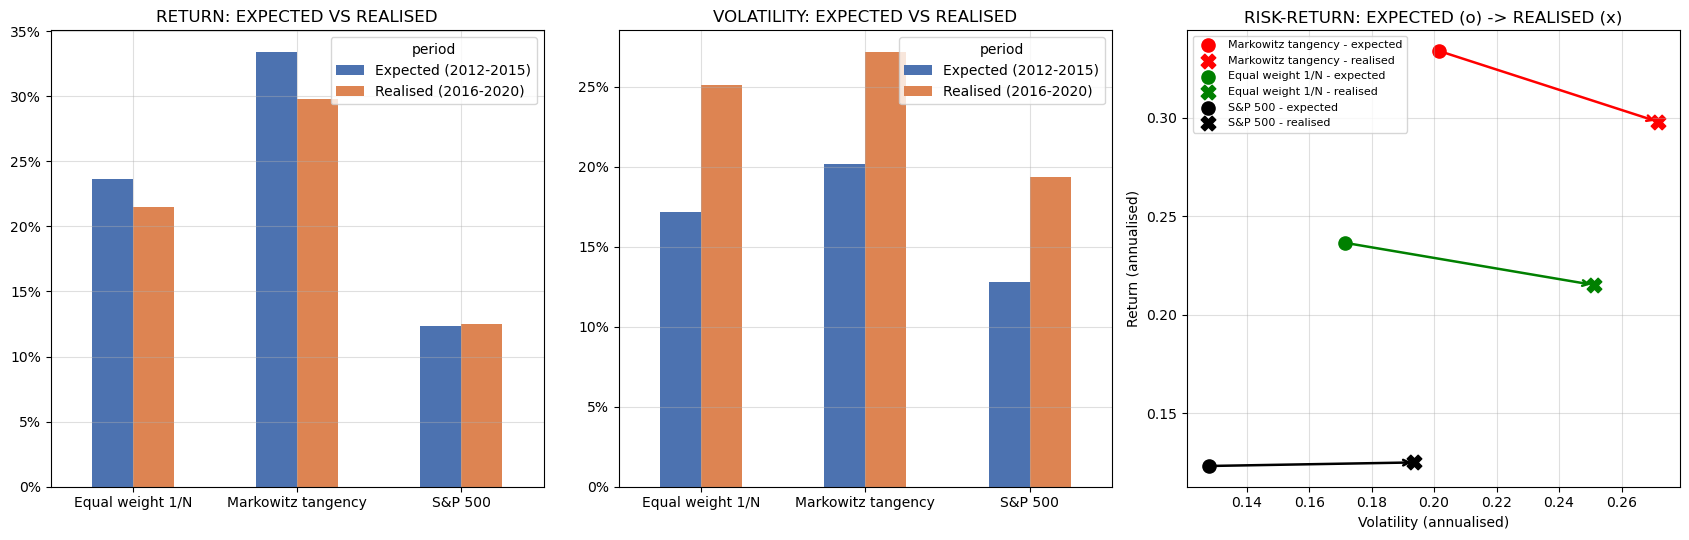

Return  Volatility  Sharpe
strategy           period                                          
Markowitz tangency Expected (2012-2015)  0.3338      0.2017  1.6551
                   Realised (2016-2020)  0.2980      0.2715  1.0976
Equal weight 1/N   Expected (2012-2015)  0.2366      0.1714  1.3803
                   Realised (2016-2020)  0.2152      0.2510  0.8573
S&P 500            Expected (2012-2015)  0.1234      0.1281  0.9631
                   Realised (2016-2020)  0.1252      0.1937  0.6463

In [25]:
def expected_vs_realised(strategies, train, test):
    # Annualised return/vol/Sharpe of fixed weights in the estimation window vs the test window
    rows = []
    for name, w in strategies.items():
        for period, data in (("Expected (2012-2015)", train), ("Realised (2016-2020)", test)):
            ret, vol, sr = portfolio_performance(w, data[w.index])
            rows.append({"strategy": name, "period": period, "Return": ret, "Volatility": vol, "Sharpe": sr})
    return pd.DataFrame(rows)


market_weight = pd.Series({BENCHMARK: 1.0})
evr = expected_vs_realised({"Markowitz tangency": weights_train,
                            "Equal weight 1/N": equal_weights,
                            "S&P 500": market_weight}, train, test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, metric in zip(axes[:2], ["Return", "Volatility"]):
    evr.pivot(index="strategy", columns="period", values=metric).plot.bar(ax=ax, rot=0, color=["#4c72b0", "#dd8452"])
    ax.set_title(f"{metric.upper()}: EXPECTED VS REALISED")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_xlabel("")

ax = axes[2]                                              # same story on the risk-return plane
for (name, grp), color in zip(evr.groupby("strategy", sort=False), ["red", "green", "black"]):
    exp_pt, real_pt = grp.iloc[0], grp.iloc[1]
    ax.annotate("", xy=(real_pt.Volatility, real_pt.Return), xytext=(exp_pt.Volatility, exp_pt.Return),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.8))
    ax.scatter(exp_pt.Volatility, exp_pt.Return, color=color, marker="o", s=90, label=f"{name} - expected")
    ax.scatter(real_pt.Volatility, real_pt.Return, color=color, marker="X", s=110, label=f"{name} - realised")
ax.set_xlabel("Volatility (annualised)")
ax.set_ylabel("Return (annualised)")
ax.set_title("RISK-RETURN: EXPECTED (o) -> REALISED (x)")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

evr.set_index(["strategy", "period"])

**Comments – Task #7 (out-of-sample test)**

**Optimal weights 2012–2015:** AMZN 26.7%, BA 23.0%, TSLA 19.9%, AAPL 10.4%, GOOG 10.1%, T 7.0%, MGM 2.5%, IBM 0.4%. These differ a lot from the full-sample weights. **Boeing gets 23% instead of 4%**, because it performed strongly in 2012–2015 before its 2019–2020 collapse, and Apple drops from 23% to 10%. The "optimal" weights depend heavily on the estimation window.

**How does it perform?** On its own terms, **well**. \$1 invested at the start of 2016 grows to **\$3.32 (CAGR 29.8%, Sharpe 1.10)**, compared with **\$1.63 for the S&P 500 (CAGR 11.2%, Sharpe 0.65)** and \$2.33 for 1/N (CAGR 20.1%, Sharpe 0.86). It captures a large part of the hindsight-optimal portfolio's performance (Sharpe 1.31).

**Expected vs realised**
- **Return held up**: 33.4% expected vs 29.8% realised, mainly because Amazon and Tesla kept winning.
- **Risk was clearly underestimated**: 20.2% expected volatility vs **27.2% realised**. The Sharpe ratio fell from **1.66 to 1.10 (−34%)**, and the maximum drawdown (−45%) was worse than the market's (−34%). Boeing's 23% weight hurt badly in 2019–2020.
- Volatility rose for *every* strategy (the S&P 500 went from 12.8% to 19.4%), because 2016–2020 includes the late-2018 sell-off and the COVID-19 crash. The Sharpe ratio fell by roughly a third for the S&P 500 and for 1/N as well. Much of the gap between expected and realised is therefore a change in **market regime**, not only a failure of the model: past volatility is not a reliable forecast of future volatility.

**Caveat.** The universe itself is chosen with hindsight: even the naive 1/N portfolio beats the S&P 500 by 9 percentage points a year. The fairer benchmark is 1/N on the same stocks, and Markowitz beat it here. That result comes from a single split with a favourable outcome (Amazon and Tesla continuing to outperform), so the optional test below checks whether it survives repeated re-estimation.

### 7.2 Optional – yearly rebalancing
One fixed estimation window may just be unlucky, so we try a rolling scheme. At the start of every year $Y$ (2013 → 2020) we estimate a new tangency portfolio on the returns of year $Y-1$ only and hold it through year $Y$. This is fully out-of-sample, because each year's weights use only data available on 1 January. We compare it with 1/N and the S&P 500 over the same 2013–2020 period.

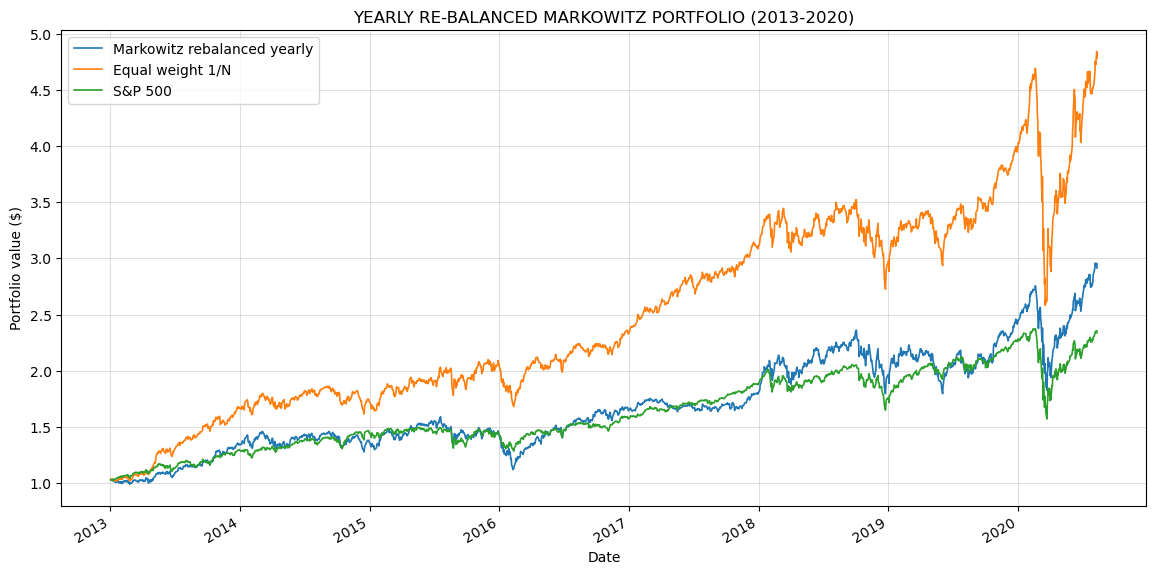

,total return,CAGR,ann. mean return,ann. vol,Sharpe,max drawdown
Markowitz rebalanced yearly,1.9144,0.1511,0.1648,0.2191,0.7522,-0.3381
Equal weight 1/N,3.7845,0.2286,0.2310,0.2228,1.0369,-0.4499
S&P 500,1.3375,0.1181,0.1264,0.1708,0.7399,-0.3392


In [26]:
def rolling_markowitz(returns, assets):
    # Each calendar year, hold the tangency portfolio estimated on the previous calendar year
    years = sorted(returns.index.year.unique())
    weights_by_year, daily_returns_ = {}, []

    for prev_year, year in zip(years[:-1], years[1:]):
        _, w, _ = simulate_portfolios(returns.loc[str(prev_year), assets])
        weights_by_year[year] = w
        daily_returns_.append(returns.loc[str(year), assets] @ w)

    strategy_returns = pd.concat(daily_returns_)
    return (1 + strategy_returns).cumprod(), pd.DataFrame(weights_by_year).T


rolling_value, rolling_weights = rolling_markowitz(returns, stocks)

oos = returns.loc[rolling_value.index]            # 2013 onwards
values_rolling = pd.DataFrame({
    "Markowitz rebalanced yearly": rolling_value,
    "Equal weight 1/N": portfolio_value(oos, equal_weights),
    "S&P 500": (1 + oos[BENCHMARK]).cumprod(),
})
plot_financial_data(values_rolling, "Yearly re-balanced Markowitz portfolio (2013-2020)", "Portfolio value ($)")
performance_summary(values_rolling)

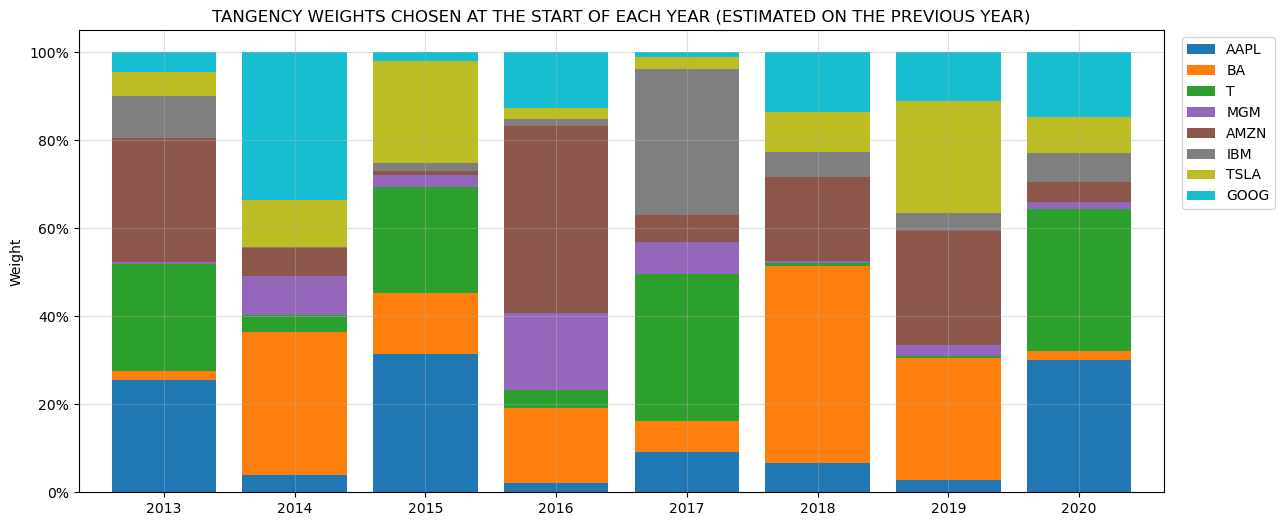

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG
2013,25.5%,2.1%,24.2%,0.4%,28.2%,9.7%,5.3%,4.5%
2014,3.8%,32.6%,3.9%,8.8%,6.3%,0.3%,10.8%,33.5%
2015,31.4%,13.9%,24.1%,2.6%,1.0%,1.7%,23.3%,1.9%
2016,2.1%,16.9%,4.2%,17.6%,42.5%,1.5%,2.4%,12.8%
2017,9.3%,6.9%,33.5%,7.2%,6.2%,33.3%,2.6%,1.1%
2018,6.7%,44.6%,0.7%,0.4%,19.1%,5.7%,9.2%,13.5%
2019,2.8%,27.7%,0.3%,2.7%,25.9%,4.2%,25.3%,11.2%
2020,30.0%,2.1%,32.2%,1.6%,4.7%,6.6%,8.2%,14.7%


,Markowitz rebalanced yearly,Equal weight 1/N,S&P 500
Date,,,
2013,34.7%,67.2%,29.6%
2014,1.1%,3.2%,11.4%
2015,5.9%,19.2%,-0.7%
2016,13.9%,13.1%,9.5%
2017,9.1%,32.6%,19.4%
2018,9.7%,-4.1%,-6.2%
2019,23.2%,33.7%,28.9%
2020,20.4%,20.8%,3.2%


In [27]:
ax = rolling_weights.plot.bar(stacked=True, figsize=(14, 6), colormap="tab10", rot=0, width=0.8)
ax.set_title("TANGENCY WEIGHTS CHOSEN AT THE START OF EACH YEAR (ESTIMATED ON THE PREVIOUS YEAR)")
ax.set_ylabel("Weight")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()
display(rolling_weights.map("{:.1%}".format))

# Calendar-year returns: did the previous year's winners keep winning?
daily_values = values_rolling.pct_change()
daily_values.iloc[0] = values_rolling.iloc[0] - 1
yearly = (1 + daily_values).groupby(daily_values.index.year).prod() - 1
yearly.map("{:.1%}".format)

**Comment – yearly rebalancing.** Re-estimating the portfolio every year makes the results **much worse**:

| 2013–2020 | Final value of \$1 | CAGR | Sharpe | Max drawdown |
|---|---|---|---|---|
| Markowitz, yearly rebalanced | \$2.91 | 15.1% | 0.75 | −33.8% |
| Equal weight 1/N | **\$4.78** | **22.9%** | **1.04** | −45.0% |
| S&P 500 | \$2.34 | 11.8% | 0.74 | −33.9% |

- The rolling Markowitz portfolio earns roughly **the market's Sharpe ratio** and **loses clearly to the naive 1/N portfolio**, beating it in only 2 of 8 years (2016 and 2018). Its one advantage is stability: returns were positive every year (+9.7% in 2018, while the S&P 500 fell 6.2%), with a smaller drawdown than 1/N.
- **The weights jump from year to year and chase the previous year's winners.** Boeing gets 33% in 2014 (after +81% in 2013) and 45% in 2018 (after +89% in 2017). AT&T and IBM together get 67% in 2017 after a good 2016, and both then fell. Amazon gets 43% in 2016 after +118% in 2015 but returned only +11%. AT&T gets 32% in 2020 just before it dropped sharply.
- **Why it fails: estimation error.** With one year of data (≈250 observations), the standard error of a stock's annual mean return is roughly as large as its volatility, often 20–40 percentage points. The mean estimates are mostly noise, and the optimiser concentrates the portfolio in exactly those noisy estimates. Last year's returns do not predict next year's. This matches DeMiguel, Garlappi & Uppal (2009), who find that the naive 1/N portfolio is very hard to beat out of sample.
- The broker's zero fees help this strategy. With real transaction costs and taxes, the high turnover would reduce its performance further.

## Conclusion
**Can we beat the market with Markowitz?**

1. **In-sample, easily.** The tangency portfolio has a Sharpe ratio of 1.43–1.50 against the S&P 500's 0.75. However, the weights were chosen with perfect hindsight on a universe full of the decade's winners.
2. **With one out-of-sample split, yes.** Weights from 2012–2015 beat the S&P 500 and 1/N over 2016–2020. Realised volatility, however, was 35% higher than expected, and the Sharpe ratio fell by a third.
3. **With realistic yearly re-estimation, no.** The strategy only matches the market's Sharpe ratio and loses clearly to a naive equal-weight portfolio. Unstable weights chasing past returns show that **estimation error in expected returns** is the Achilles' heel of mean-variance optimisation.

**Recommendation to the fund manager.** Do not implement the raw tangency weights. A robust approach would
- use longer estimation windows and shrink expected returns and covariances (e.g. Ledoit–Wolf, Black–Litterman), or drop expected returns and use a minimum-variance portfolio;
- impose position caps, which regulated funds require anyway (e.g. max 10% per issuer under UCITS);
- always compare against the simple 1/N benchmark out of sample.